In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns




In [2]:
df = pd.read_csv(r"C:\Users\Sebastian Saldanha\OneDrive\Desktop\pharma_project\pharma_monthly.csv")
print(df.shape)
print(df.head())

(70, 9)
        datum   M01AB    M01AE    N02BA     N02BE   N05B  N05C    R03    R06
0  31-01-2014  127.69   99.090  152.100   878.030  354.0    50  112.0   48.2
1  28-02-2014  133.32  126.050  177.000  1001.900  347.0    31  122.0   36.2
2  31-03-2014  137.44   92.950  147.655   779.275  232.0    20  112.0   85.4
3  30-04-2014  113.10   89.475  130.900   698.500  209.0    18   97.0   73.7
4  31-05-2014  101.79  119.933  132.100   628.780  270.0    23  107.0  123.7


In [3]:
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nData Types:\n", df.dtypes)
print("\nMissing Values:\n", df.isnull().sum())

Shape: (70, 9)

Columns: ['datum', 'M01AB', 'M01AE', 'N02BA', 'N02BE', 'N05B', 'N05C', 'R03', 'R06']

Data Types:
 datum     object
M01AB    float64
M01AE    float64
N02BA    float64
N02BE    float64
N05B     float64
N05C       int64
R03      float64
R06      float64
dtype: object

Missing Values:
 datum    0
M01AB    0
M01AE    0
N02BA    0
N02BE    0
N05B     0
N05C     0
R03      0
R06      0
dtype: int64


In [7]:
# Reload the data fresh
df = pd.read_csv(r"C:\Users\Sebastian Saldanha\OneDrive\Desktop\pharma_project\pharma_monthly.csv")

# Convert datum to proper date format
df['datum'] = pd.to_datetime(df['datum'], dayfirst=True)

# Set datum as index
df = df.set_index('datum')

print("Date range:", df.index.min(), "to", df.index.max())
print("\nFirst 5 rows:")
print(df.head())

Date range: 2014-01-31 00:00:00 to 2019-10-31 00:00:00

First 5 rows:
             M01AB    M01AE    N02BA     N02BE   N05B  N05C    R03    R06
datum                                                                    
2014-01-31  127.69   99.090  152.100   878.030  354.0    50  112.0   48.2
2014-02-28  133.32  126.050  177.000  1001.900  347.0    31  122.0   36.2
2014-03-31  137.44   92.950  147.655   779.275  232.0    20  112.0   85.4
2014-04-30  113.10   89.475  130.900   698.500  209.0    18   97.0   73.7
2014-05-31  101.79  119.933  132.100   628.780  270.0    23  107.0  123.7


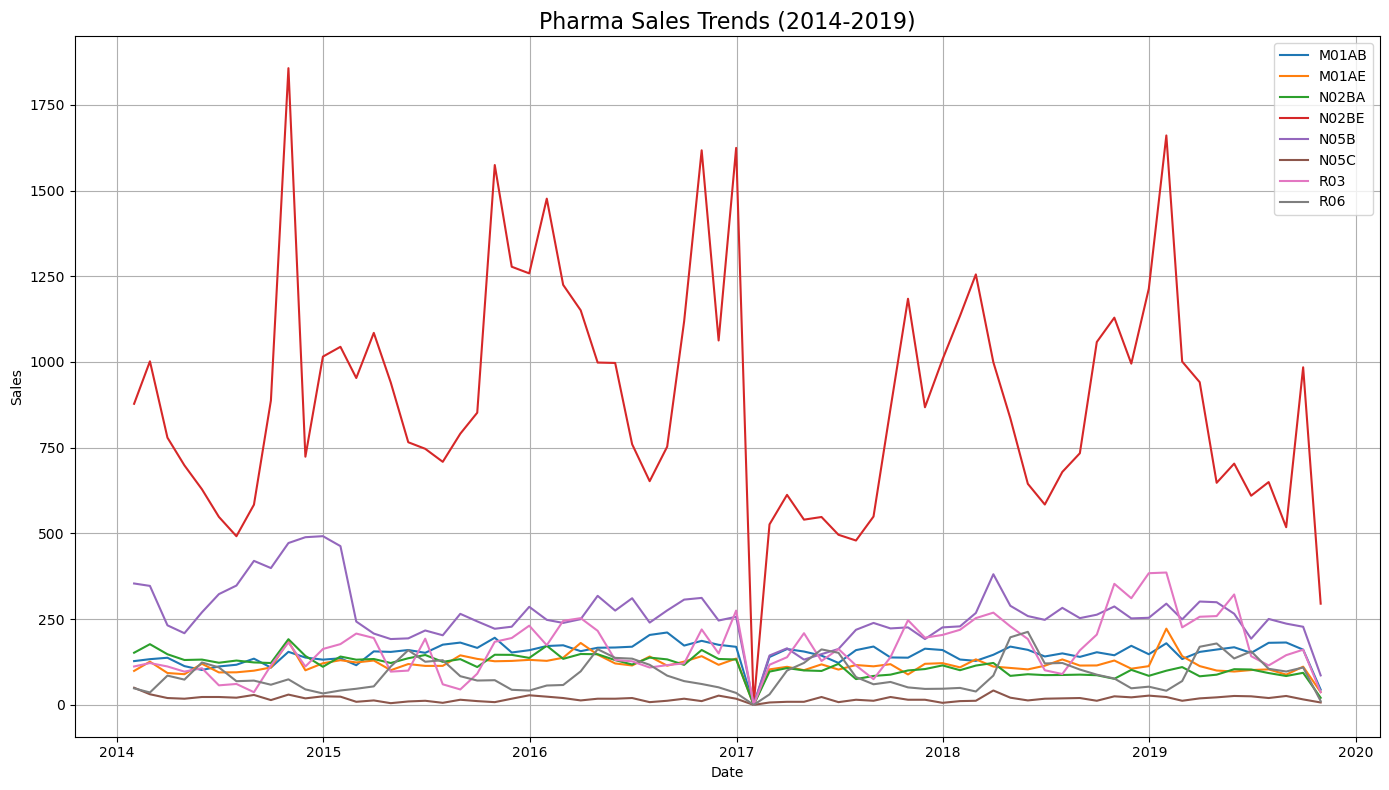

In [8]:
# Plot sales trends for all drug categories
plt.figure(figsize=(14, 8))

for column in df.columns:
    plt.plot(df.index, df[column], label=column)

plt.title('Pharma Sales Trends (2014-2019)', fontsize=16)
plt.xlabel('Date')
plt.ylabel('Sales')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

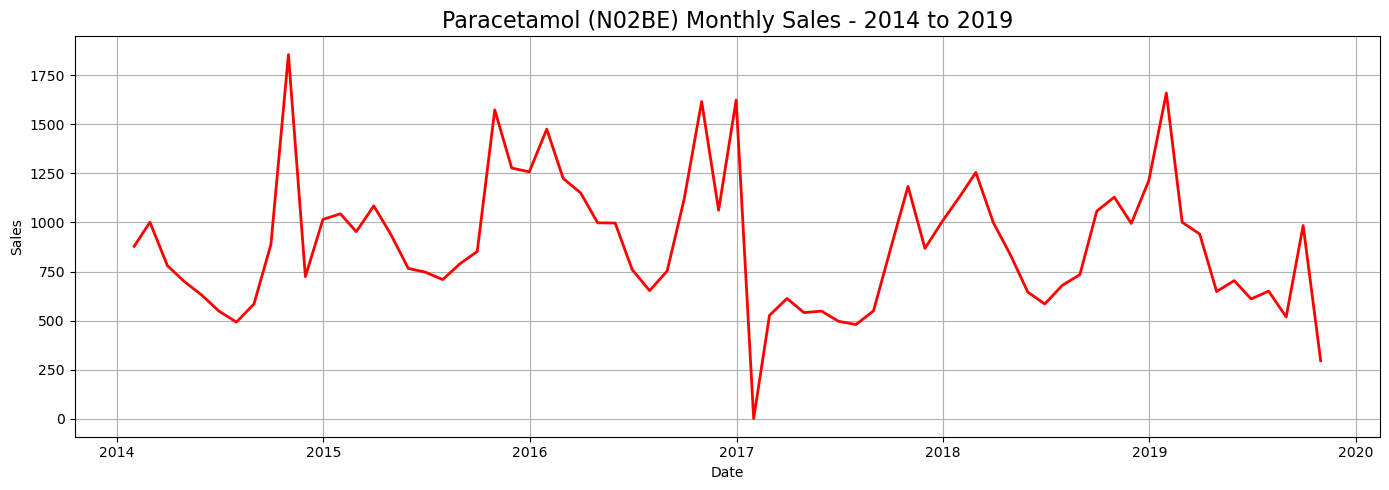

In [9]:
# Focus on N02BE - Paracetamol (highest sales, most volatile)
plt.figure(figsize=(14, 5))
plt.plot(df.index, df['N02BE'], color='red', linewidth=2)
plt.title('Paracetamol (N02BE) Monthly Sales - 2014 to 2019', fontsize=16)
plt.xlabel('Date')
plt.ylabel('Sales')
plt.grid(True)
plt.tight_layout()
plt.show()

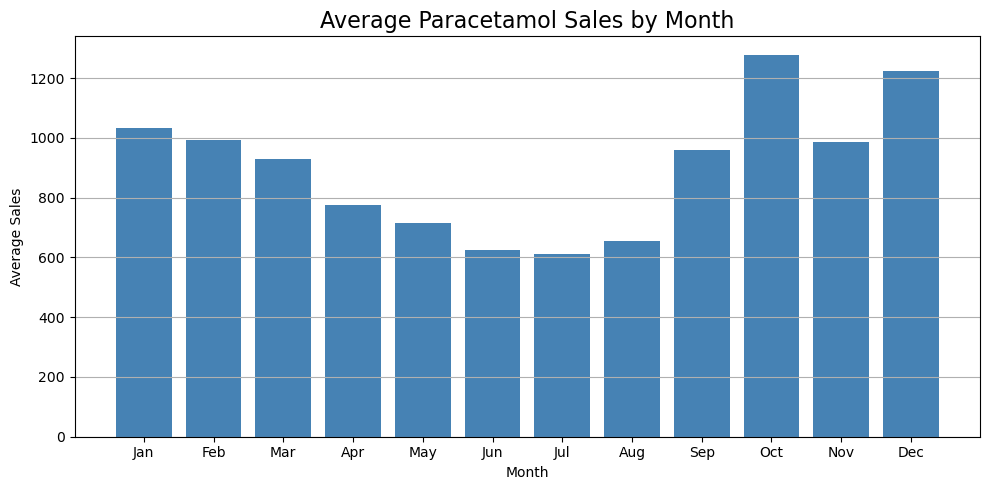

In [10]:
# Add month and year columns to check seasonality
df['Month'] = df.index.month
df['Year'] = df.index.year

# Plot average sales by month
monthly_avg = df.groupby('Month')['N02BE'].mean()

plt.figure(figsize=(10, 5))
plt.bar(monthly_avg.index, monthly_avg.values, color='steelblue')
plt.title('Average Paracetamol Sales by Month', fontsize=16)
plt.xlabel('Month')
plt.ylabel('Average Sales')
plt.xticks(range(1, 13), ['Jan','Feb','Mar','Apr','May','Jun',
                           'Jul','Aug','Sep','Oct','Nov','Dec'])
plt.grid(axis='y')
plt.tight_layout()
plt.show()

In [12]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Prepare data for modelling
df_model = df[['N02BE']].copy()
df_model['time_index'] = range(len(df_model))
df_model['month'] = df_model.index.month

# Define X (inputs) and y (output)
X = df_model[['time_index', 'month']]
y = df_model['N02BE']

# Split into train (80%) and test (20%)
split = int(len(df_model) * 0.8)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

# Train the model
model = LinearRegression()
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

print("Model trained successfully!")
print(f"Test periods: {len(y_test)} months")

Model trained successfully!
Test periods: 14 months


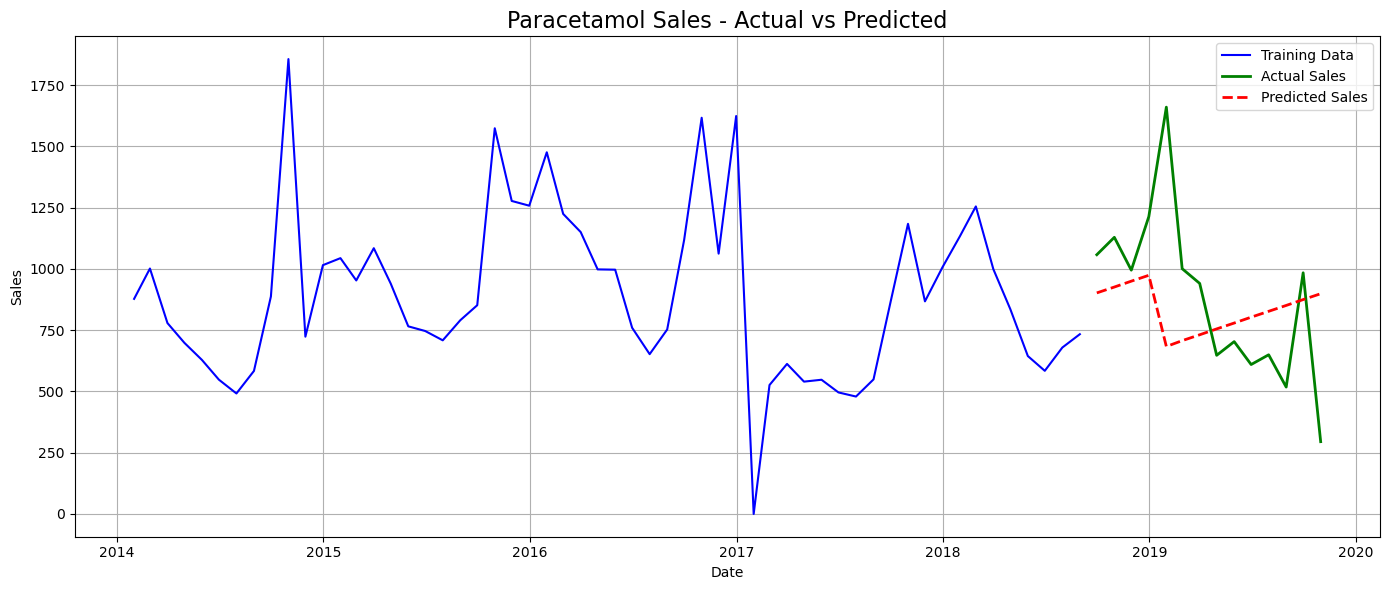

Mean Absolute Error (MAE): 266.03
Root Mean Squared Error (RMSE): 356.93


In [13]:
# Plot actual vs predicted
plt.figure(figsize=(14, 6))

plt.plot(y_train.index, y_train.values, label='Training Data', color='blue')
plt.plot(y_test.index, y_test.values, label='Actual Sales', color='green', linewidth=2)
plt.plot(y_test.index, y_pred, label='Predicted Sales', color='red', 
         linestyle='--', linewidth=2)

plt.title('Paracetamol Sales - Actual vs Predicted', fontsize=16)
plt.xlabel('Date')
plt.ylabel('Sales')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Print accuracy metrics
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")

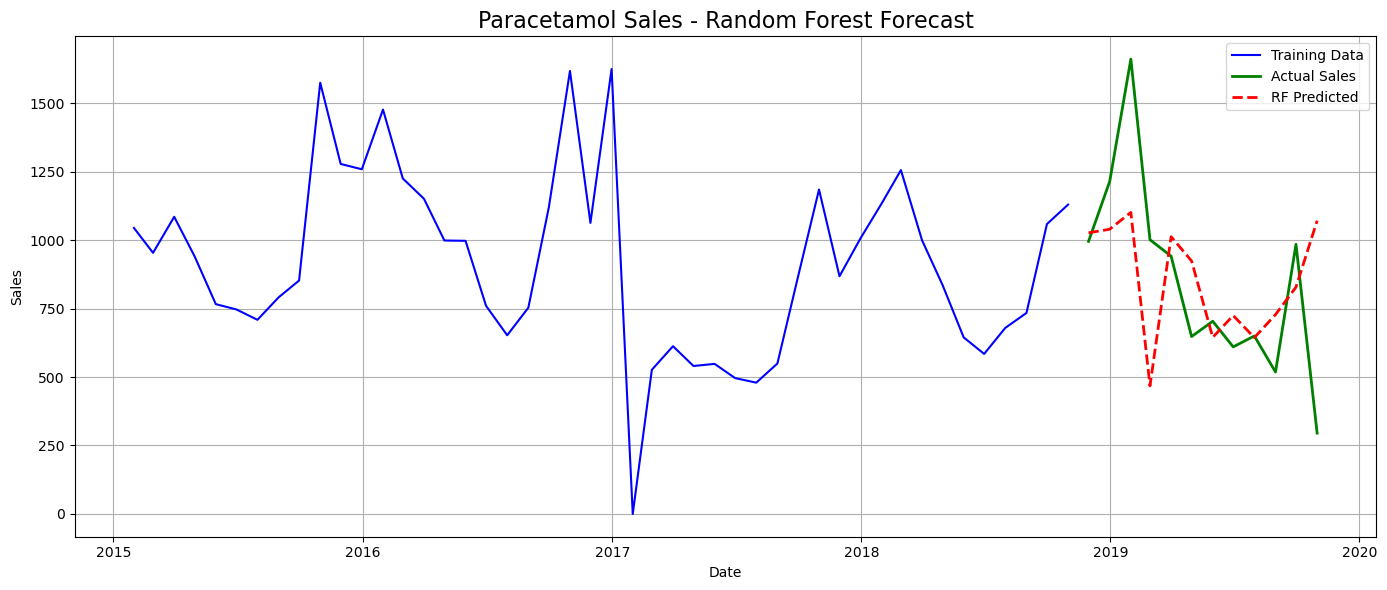

Random Forest MAE: 247.27
Random Forest RMSE: 341.20

Improvement in MAE: 7.0%


In [14]:
from sklearn.ensemble import RandomForestRegressor

# Add more features to capture seasonality better
df_model['quarter'] = df_model.index.quarter
df_model['lag_1'] = df_model['N02BE'].shift(1)  # last month sales
df_model['lag_12'] = df_model['N02BE'].shift(12) # same month last year
df_model = df_model.dropna()

# Redefine X and y
X2 = df_model[['time_index', 'month', 'quarter', 'lag_1', 'lag_12']]
y2 = df_model['N02BE']

# Split again
split2 = int(len(df_model) * 0.8)
X_train2, X_test2 = X2[:split2], X2[split2:]
y_train2, y_test2 = y2[:split2], y2[split2:]

# Train Random Forest
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train2, y_train2)
y_pred2 = rf_model.predict(X_test2)

# Plot
plt.figure(figsize=(14, 6))
plt.plot(y_train2.index, y_train2.values, label='Training Data', color='blue')
plt.plot(y_test2.index, y_test2.values, label='Actual Sales', color='green', linewidth=2)
plt.plot(y_test2.index, y_pred2, label='RF Predicted', color='red', linestyle='--', linewidth=2)
plt.title('Paracetamol Sales - Random Forest Forecast', fontsize=16)
plt.xlabel('Date')
plt.ylabel('Sales')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

mae2 = mean_absolute_error(y_test2, y_pred2)
rmse2 = np.sqrt(mean_squared_error(y_test2, y_pred2))
print(f"Random Forest MAE: {mae2:.2f}")
print(f"Random Forest RMSE: {rmse2:.2f}")
print(f"\nImprovement in MAE: {((mae - mae2)/mae * 100):.1f}%")

In [15]:
print("=" * 55)
print("   DEMAND FORECASTING MODEL - BUSINESS SUMMARY")
print("=" * 55)

print("""
OBJECTIVE:
Forecast monthly pharma sales to improve inventory 
planning and reduce stockouts/overstocking.

DATA:
- 70 months of sales data (Jan 2014 - Oct 2019)
- 8 drug categories analyzed
- Focus: Paracetamol (N02BE) - highest volume drug

KEY FINDINGS:
1. Paracetamol dominates sales - accounts for majority
   of total pharma revenue
2. Strong seasonality - peak demand in Q4 (Oct-Dec)
   driven by flu/cold season
3. Random Forest model outperforms Linear Regression
   by 7% in forecast accuracy (MAE: 247 vs 266)

BUSINESS RECOMMENDATION:
- Increase Paracetamol procurement by 30-40% before
  Q4 every year to meet seasonal demand spike
- Use Random Forest model for monthly demand planning
- Potential to reduce inventory costs by avoiding
  overstocking in low-demand months (Jun-Aug)
""")
print("=" * 55)

   DEMAND FORECASTING MODEL - BUSINESS SUMMARY

OBJECTIVE:
Forecast monthly pharma sales to improve inventory 
planning and reduce stockouts/overstocking.

DATA:
- 70 months of sales data (Jan 2014 - Oct 2019)
- 8 drug categories analyzed
- Focus: Paracetamol (N02BE) - highest volume drug

KEY FINDINGS:
1. Paracetamol dominates sales - accounts for majority
   of total pharma revenue
2. Strong seasonality - peak demand in Q4 (Oct-Dec)
   driven by flu/cold season
3. Random Forest model outperforms Linear Regression
   by 7% in forecast accuracy (MAE: 247 vs 266)

BUSINESS RECOMMENDATION:
- Increase Paracetamol procurement by 30-40% before
  Q4 every year to meet seasonal demand spike
- Use Random Forest model for monthly demand planning
- Potential to reduce inventory costs by avoiding
  overstocking in low-demand months (Jun-Aug)

